# ML Pipeline — CpG Methylation Analysis (Block Analysis)
## Step 2: Unsupervised + Supervised Learning per Dataset

**How to use this notebook:**
1. In Cell 2, set `DATASET`
2. Run all cells top to bottom (Cell menu → Run All)
3. Change `DATASET` and run again for the next dataset

**Available datasets:** stress, wildfire, obesity_hippocampus, obesity_hypothalamus, obesity_prefrontalcortex, cfdna_GD45, cfdna_GD90, cfdna_GD120, cfdna_GD150

**Region:** Full block chr10:2,307,563-2,441,516 (~134 kb) — single matrix per dataset, no sub-window split.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut,
    cross_val_score, cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
import umap

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## Cell 2 — Configuration

**Change `DATASET` to switch datasets.**

`PROJECT_ROOT` goes two levels up (block_analysis/notebooks/ -> notebooks/ -> project root).
All results are saved under `results/figures/block_analysis/` and `results/tables/block_analysis/`
so they stay separate from the original pipeline outputs.


In [2]:
# ── Change this to run a different dataset ──────────────────────────
DATASET = 'cfdna_GD150'      # dataset key

# ── Paths ─────────────────────────────────────────────────────────────
# block_analysis notebooks live two levels below project root
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed' / 'block_analysis'
FIGURES_DIR  = PROJECT_ROOT / 'results' / 'figures' / 'block_analysis'
TABLES_DIR   = PROJECT_ROOT / 'results' / 'tables'  / 'block_analysis'

for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Dataset sizes — controls CV strategy ─────────────────────────────
# n < 30  → LOOCV (leave-one-out cross-validation)
# n >= 30 → 5-fold stratified CV
# n >= 40 → also run Random Forest
DATASET_SIZES = {
    'stress'                  : 76,
    'wildfire'                : 21,
    'obesity_hippocampus'     : 13,
    'obesity_hypothalamus'    : 13,
    'obesity_prefrontalcortex': 13,
    'cfdna_GD45'              : 11,
    'cfdna_GD90'              : 11,
    'cfdna_GD120'             : 12,
    'cfdna_GD150'             : 13,
}
LABEL = DATASET
N = DATASET_SIZES[DATASET]

print(f'Dataset      : {DATASET}')
print(f'Region       : fullblock  (chr10:2,307,563-2,441,516 ~134 kb)')
print(f'Sample size  : {N}')
print(f'CV strategy  : {"LOOCV" if N < 30 else "5-fold stratified CV"}')


Dataset      : cfdna_GD150
Region       : fullblock  (chr10:2,307,563-2,441,516 ~134 kb)
Sample size  : 13
CV strategy  : LOOCV


## Cell 3 — Load Data

**What to remember:**
- `pd.read_csv(..., index_col=0)` — the first column (CpG positions) becomes the row index
- After loading, we **transpose** with `.T` so rows = samples and columns = CpGs (sklearn format)
- `labels.loc[X.index]` reorders labels to match the sample order in X — always do this

**File loaded:** `{DATASET}_fullblock_methylation.csv` from `data/processed/block_analysis/`


In [4]:
# Load beta matrix: CpGs x samples -> transpose to samples x CpGs
beta_path  = DATA_DIR / f'{DATASET}_fullblock_methylation.csv'
label_path = DATA_DIR / f'{DATASET}_labels.csv'

X_raw = pd.read_csv(beta_path, index_col=0)
# X_raw: rows=CpGs, columns=samples (as saved by preprocessing notebook)

labels = pd.read_csv(label_path, index_col='sample_id', dtype={'sample_id': str})

# Transpose so rows=samples, columns=CpGs (sklearn format)
X = X_raw.T
# Before: (n_CpGs x n_samples) -> After: (n_samples x n_CpGs)

# Align labels to sample order in X
y = labels.loc[X.index, 'label']
# .loc[X.index] reorders labels to match the sample order in X

n_ctrl = (y == 0).sum()
n_case = (y == 1).sum()

print(f'X shape  : {X.shape}   (samples x CpGs)')
print(f'y counts : {n_ctrl} ctrl / {n_case} case')
print(f'Any NaNs : {X.isna().any().any()}  (should be False)')


X shape  : (13, 2701)   (samples x CpGs)
y counts : 6 ctrl / 7 case
Any NaNs : False  (should be False)


## Cell 4 — PCA (Principal Component Analysis)

**What PCA does:** Finds the directions of maximum variance in your data. Each principal component (PC) is a linear combination of all CpGs. PC1 captures the most variance, PC2 the second most, etc.

**What to look for:**
- Do Control and Case samples separate along PC1 or PC2? That suggests methylation differences
- If samples cluster by group → good signal for ML
- If completely mixed → weak or no signal at this region

**What to remember:**
- `StandardScaler()` — subtracts mean and divides by std per CpG before PCA. Always scale before PCA — otherwise CpGs with higher variance dominate just because of scale, not biology
- `explained_variance_ratio_` — fraction of total variance each PC captures
- `pca.components_` — the CpG loadings (which CpGs drive each PC)

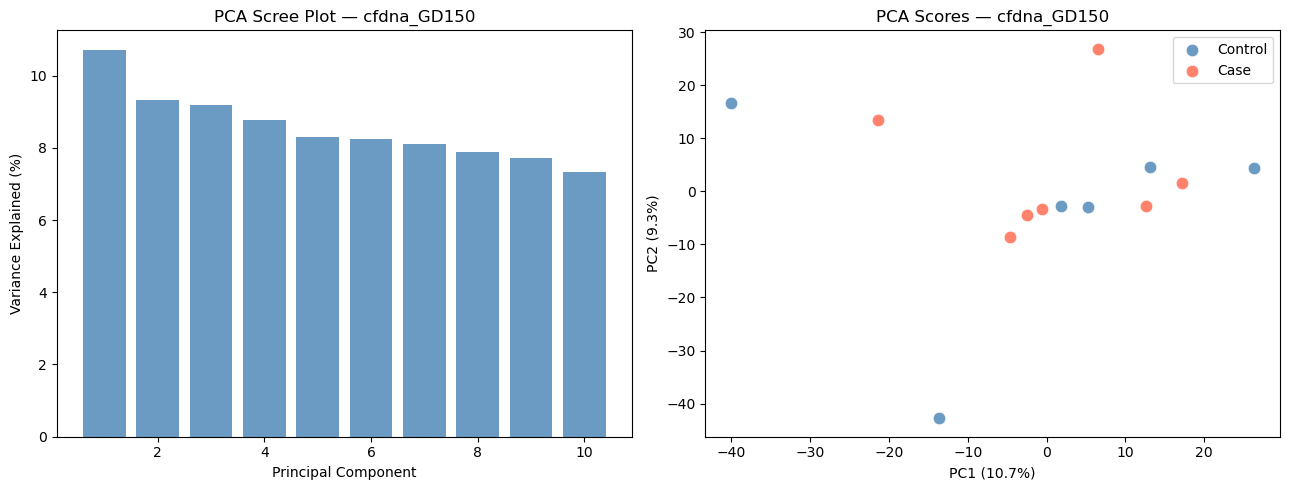

Saved: pca_cfdna_GD150.png

Top 5 CpGs driving PC1 (by absolute loading):


CpG_start
2367780    0.055585
2335902    0.051325
2405348    0.050648
2386087    0.049265
2347649    0.049253
Name: PC1, dtype: float64

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# fit_transform: learns mean/std from data AND applies scaling in one step
# Result: each CpG has mean=0 and std=1 across samples

n_components = min(10, X.shape[0] - 1)
# Can't have more components than (n_samples - 1)

pca = PCA(n_components=n_components, random_state=42)
coords = pca.fit_transform(X_scaled)
# coords: each row = one sample, each column = one PC
# coords[:, 0] = PC1 scores, coords[:, 1] = PC2 scores

explained = pca.explained_variance_ratio_ * 100
# Multiply by 100 to get percentages

# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot — how much variance does each PC explain?
axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title(f'PCA Scree Plot — {LABEL}')
# A scree plot tells you how many PCs are meaningful
# Look for an "elbow" — PCs after the elbow add little information

# PC1 vs PC2 scatter plot
colors = {0: 'steelblue', 1: 'tomato'}
group_labels = {0: 'Control', 1: 'Case'}

for val in [0, 1]:
    mask = y == val
    axes[1].scatter(
        coords[mask, 0], coords[mask, 1],
        c=colors[val], label=group_labels[val],
        alpha=0.8, s=80, edgecolors='white', linewidths=0.5
    )

axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[1].set_title(f'PCA Scores — {LABEL}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'pca_{LABEL}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: pca_{LABEL}.png')

# ── Top CpG loadings ─────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)
print(f'\nTop 5 CpGs driving PC1 (by absolute loading):')
display(loadings['PC1'].abs().sort_values(ascending=False).head(5))
loadings.to_csv(TABLES_DIR / f'pca_loadings_{LABEL}.csv')

## Cell 5 — UMAP

**What UMAP does:** Non-linear dimensionality reduction. Unlike PCA which finds global linear structure, UMAP preserves local neighbourhood relationships. Samples that are similar in methylation space end up close together.

**What to remember:**
- UMAP is not reliable with n < 15 — with very few samples, the neighbourhood structure is meaningless
- `n_neighbors` controls how local vs global the structure is. Small value = focus on local structure. We use `max(5, n//3)` to scale with sample size
- UMAP is stochastic — results can vary slightly between runs. `random_state=42` makes it reproducible
- UMAP is for **visualization only** — never use UMAP coordinates as input to ML models

In [6]:
if N < 15:
    print(f'[SKIP] UMAP skipped — n={N} is too small (minimum 15)')
    print('UMAP needs enough samples to build meaningful neighbourhoods')
else:
    n_neighbors = max(5, N // 3)
    # n_neighbors scales with dataset size
    # Too small → noisy, too large → loses local structure

    reducer = umap.UMAP(
        n_components=2,
        random_state=42,     # reproducibility
        n_neighbors=n_neighbors,
        min_dist=0.1         # how tightly points cluster together
    )
    umap_coords = reducer.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(7, 6))
    for val in [0, 1]:
        mask = y == val
        ax.scatter(
            umap_coords[mask, 0], umap_coords[mask, 1],
            c=colors[val], label=group_labels[val],
            alpha=0.8, s=80, edgecolors='white', linewidths=0.5
        )
    ax.set_title(f'UMAP — {LABEL} (n_neighbors={n_neighbors})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'umap_{LABEL}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: umap_{LABEL}.png')

[SKIP] UMAP skipped — n=13 is too small (minimum 15)
UMAP needs enough samples to build meaningful neighbourhoods


## Cell 6 — Hierarchical Clustering Heatmap

**What it shows:** A heatmap of beta values (methylation) with samples clustered by similarity (rows) and CpGs clustered by co-methylation pattern (columns). The color bar on the left shows Control (blue) vs Case (red).

**What to look for:**
- Do Control samples cluster together, away from Case? → clear methylation difference
- Are there blocks of CpGs with consistently high/low methylation in one group?

**What to remember:**
- `method='ward'` — Ward linkage minimises within-cluster variance. Standard choice for methylation data
- `metric='euclidean'` — distance measure between samples
- `vmin=0, vmax=1` — fixes colour scale to beta value range so all plots are comparable across datasets

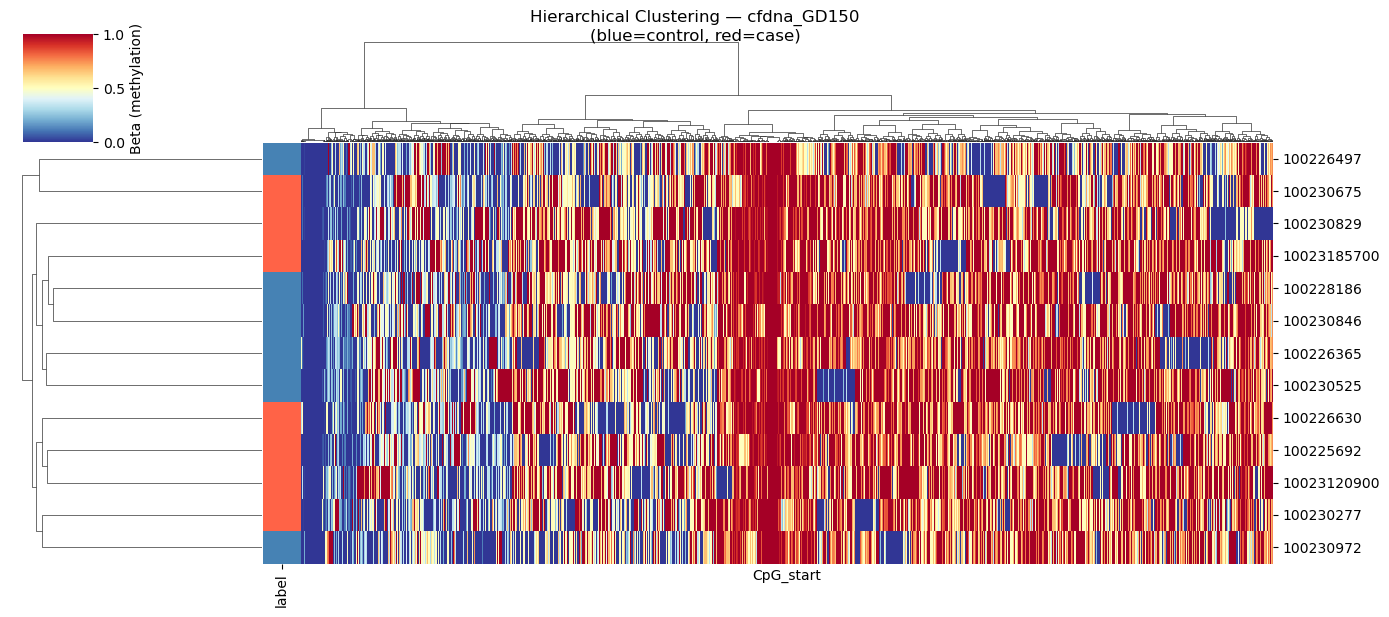

Saved: clustermap_cfdna_GD150.png


In [7]:
condition_colors = y.map({0: 'steelblue', 1: 'tomato'})
# Maps 0→blue, 1→red — used as the row colour bar

g = sns.clustermap(
    X,
    row_colors=condition_colors,   # colour bar showing group
    cmap='RdYlBu_r',               # Red=high methylation, Blue=low
    vmin=0, vmax=1,                # fix scale to beta range
    figsize=(14, max(6, N * 0.35)),
    yticklabels=True,
    xticklabels=False,             # too many CpGs to label
    method='ward',                 # linkage method for clustering
    metric='euclidean',
    cbar_kws={'label': 'Beta (methylation)'}
)
g.fig.suptitle(
    f'Hierarchical Clustering — {LABEL}\n'
    f'(blue=control, red=case)',
    y=1.02, fontsize=12
)
plt.savefig(FIGURES_DIR / f'clustermap_{LABEL}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: clustermap_{LABEL}.png')

## Cell 7 — ElasticNet Logistic Regression

**Why ElasticNet?** With p CpGs >> n samples (many features, few samples), regular logistic regression overfits. ElasticNet adds two regularisation penalties:
- **L1 (Lasso)** — drives small coefficients to exactly zero → feature selection (identifies which CpGs matter)
- **L2 (Ridge)** — shrinks all coefficients → handles correlated CpGs

`l1_ratio=0.5` means equal mix of both. This is ideal for methylation data where nearby CpGs are correlated.

**What to remember:**
- **LOOCV** (n<30): leave one sample out, train on the rest, predict the left-out sample. Repeat for every sample. Best for small n
- **5-fold CV** (n≥30): split data into 5 folds, train on 4, test on 1, repeat 5 times
- **AUC** (Area Under ROC Curve): 0.5 = random, 1.0 = perfect. AUC > 0.7 is generally considered useful
- **Non-zero coefficients**: which CpGs ElasticNet kept as informative (L1 drives the rest to zero)

In [8]:
# Choose CV strategy based on sample size
if N < 30:
    cv      = LeaveOneOut()
    cv_name = 'LOOCV'
else:
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_name = '5-fold CV'
    # StratifiedKFold preserves class proportions in each fold
    # Important when classes are imbalanced (e.g. stress: 52 ctrl vs 24 case)

# Build pipeline: scale → classify
# Pipeline ensures scaling is fitted on training data only
# (prevents data leakage — a common ML mistake)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='elasticnet',
        solver='saga',          # only solver that supports elasticnet
        l1_ratio=0.5,           # equal L1 + L2 mix
        C=1.0,                  # regularisation strength (lower = stronger)
        # C=0.1 was too strong for ~42 CpGs — zeroed all coefficients
        # C=1.0 allows ElasticNet to keep informative CpGs
        max_iter=3000,
        random_state=42
    ))
])

# Cross-validated predictions
if isinstance(cv, LeaveOneOut):
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    # predict_proba returns [P(class=0), P(class=1)] — we take column 1
    auc = roc_auc_score(y, y_proba)
    acc = cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean()
    print(f'ElasticNet ({cv_name}):')
    print(f'  AUC = {auc:.3f}')
    print(f'  Accuracy = {acc:.3f}')
else:
    aucs = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    accs = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    auc, acc = aucs.mean(), accs.mean()
    print(f'ElasticNet ({cv_name}):')
    print(f'  AUC = {auc:.3f} ± {aucs.std():.3f}')
    print(f'  Accuracy = {acc:.3f} ± {accs.std():.3f}')

# Fit on ALL data to get CpG coefficients
model.fit(X, y)
coefs = pd.Series(
    model.named_steps['clf'].coef_[0],
    index=X.columns
)
nonzero = coefs[coefs != 0].sort_values(key=abs, ascending=False)
print(f'\n  {len(nonzero)} non-zero CpG coefficients (out of {len(coefs)})')
print(f'  Top 5 CpGs by absolute coefficient:')
display(nonzero.head())

# Save coefficients
coefs.to_csv(TABLES_DIR / f'elasticnet_coefs_{LABEL}.csv', header=['coefficient'])
print(f'\nSaved: elasticnet_coefs_{LABEL}.csv')

ElasticNet (LOOCV):
  AUC = 0.214
  Accuracy = 0.308

  63 non-zero CpG coefficients (out of 2701)
  Top 5 CpGs by absolute coefficient:


CpG_start
2423805   -0.229144
2423839   -0.174413
2431697   -0.172835
2417945   -0.150201
2326206   -0.147157
dtype: float64


Saved: elasticnet_coefs_cfdna_GD150.csv


## Cell 8 — Random Forest (stress dataset only)

**Why only for stress (n=76)?** Random Forest builds many decision trees on random subsets of samples and features. It needs enough samples per class to learn reliable patterns. With n=13, it would memorise the training data (overfit).

**What to remember:**
- `n_estimators=500` — 500 trees. More trees = more stable but slower. 500 is standard
- `oob_score=True` — Out-of-Bag score: each tree is trained on ~63% of samples, the remaining ~37% (out-of-bag) are used as a built-in validation set. Free estimate of generalisation error
- `max_features='sqrt'` — each split considers √n_CpGs features. Reduces correlation between trees
- Feature importance from Random Forest measures **mean decrease in impurity** — how much each CpG reduces uncertainty across all trees

In [9]:
if N < 40:
    print(f'[SKIP] Random Forest skipped — n={N}')
    print(f'Random Forest needs n≥40 for reliable estimates. Use ElasticNet results above.')
else:
    rf = RandomForestClassifier(
        n_estimators=500,
        max_features='sqrt',
        oob_score=True,       # free out-of-bag validation
        n_jobs=-1,            # use all available CPU cores
        random_state=42
    )

    cv_rf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs_rf = cross_val_score(rf, X, y, cv=cv_rf, scoring='roc_auc')
    accs_rf = cross_val_score(rf, X, y, cv=cv_rf, scoring='accuracy')

    print(f'Random Forest (5-fold CV):')
    print(f'  AUC = {aucs_rf.mean():.3f} ± {aucs_rf.std():.3f}')
    print(f'  Accuracy = {accs_rf.mean():.3f} ± {accs_rf.std():.3f}')

    # Fit on all data for feature importance
    rf.fit(X, y)
    print(f'  OOB score: {rf.oob_score_:.3f}')
    # OOB score ~ accuracy on held-out samples during training

    importance = pd.Series(rf.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=False)

    # Plot top 20 CpGs
    plt.figure(figsize=(10, 5))
    importance.head(20).plot(kind='bar', color='steelblue', alpha=0.8)
    plt.title(f'Random Forest — Top 20 CpG Importances — {LABEL}')
    plt.xlabel('CpG position')
    plt.ylabel('Mean Decrease in Impurity')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'rf_importance_{LABEL}.png', dpi=150, bbox_inches='tight')
    plt.show()

    importance.to_csv(TABLES_DIR / f'rf_importance_{LABEL}.csv', header=['importance'])
    print(f'Saved: rf_importance_{LABEL}.png and rf_importance_{LABEL}.csv')

[SKIP] Random Forest skipped — n=13
Random Forest needs n≥40 for reliable estimates. Use ElasticNet results above.


## Cell 9 — Results Summary

Collect all results in one place for easy comparison across datasets.
Run this after completing all datasets to build up the summary table.

In [10]:
summary = {
    'dataset'   : DATASET,
    'region'    : 'fullblock',
    'n_samples' : N,
    'n_ctrl'    : int((y == 0).sum()),
    'n_case'    : int((y == 1).sum()),
    'n_cpgs'    : X.shape[1],
    'cv_method' : cv_name,
    'auc'       : round(auc, 3),
    'accuracy'  : round(acc, 3),
    'elasticnet_nonzero_cpgs': len(nonzero),
}

print('-- Results Summary --')
for k, v in summary.items():
    print(f'  {k:30s}: {v}')

# Append to running summary file
summary_path = TABLES_DIR / 'ml_results_summary.csv'
summary_df   = pd.DataFrame([summary])

if summary_path.exists():
    existing = pd.read_csv(summary_path)
    # Remove old entry for this dataset if it exists
    existing = existing[existing['dataset'] != DATASET]
    summary_df = pd.concat([existing, summary_df], ignore_index=True)

summary_df.to_csv(summary_path, index=False)
print(f'\nAppended to: results/tables/block_analysis/ml_results_summary.csv')


-- Results Summary --
  dataset                       : cfdna_GD150
  region                        : fullblock
  n_samples                     : 13
  n_ctrl                        : 6
  n_case                        : 7
  n_cpgs                        : 2701
  cv_method                     : LOOCV
  auc                           : 0.214
  accuracy                      : 0.308
  elasticnet_nonzero_cpgs       : 63

Appended to: results/tables/block_analysis/ml_results_summary.csv
